# TUTORIEL EPSILON : GRAPHIQUES AVEC PYTHON

In [3]:
#%matplotlib inline sets the backend of matplotlib to the 'inline' backend: With this backend, the output of plotting commands is displayed inline within frontends like the Jupyter notebook, directly below the code cell that produced it. The resulting plots will then also be stored in the notebook document.
%matplotlib inline
import matplotlib.pyplot as plt

# 1. get iris data

In [4]:
from sklearn import datasets
iris = datasets.load_iris()

# 2. matplotlib key concepts

## 2.1 general
* matplotlib is a complete plotting package that offers in the same time high level commands to assist users to visualize their data as simple as possible. but have also the ability to use low level commands 

* In this tutorial we will use the top level commands provided by the matplotlib.pyplot module that we have just imported `import matplotlib.pyplot as plt`

* plt behave as matlab so users experienced with matlab plotting will be most familiar with plt

* the low level commands are used generally to embed plots to GUI

## 2.2 Parts of a figure

![Alt text](https://matplotlib.org/_images/anatomy.png)

### 2.2.1 Figure
* A figure in matplotlib is the whole figure
* the previous image is a figure
* A figure can have none or more axes (see below for the definition of axe), we say that axes are childs of the figure
* to create an empty figure we use the command : `fig = plt.figure`

In [5]:
# create an empty figure (figure with 0 axes)
fig = plt.figure()
fig.suptitle("title of an empty figure")

Text(0.5, 0.98, 'title of an empty figure')

<Figure size 432x288 with 0 Axes>

* to create a figure with multiple subplots or axes, we use the commande : in this case we create a figure with 4 axes in a grid of shape (2,2) 
```
fig, ax_list = plt.subplots(nrows=2, ncols=2)
```

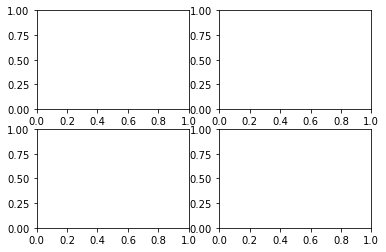

In [6]:
# create a figure with a set of subplots (axes)
fig, ax_list = plt.subplots(nrows=2, ncols=2)

### 2.2.1 Axes
* this is what we think of as a plot
* So a figure can have multiple **axes**, each **axe** is associated to one figure
* Each axe contain 2 **axis** (or 3 in case of 3D) the define the data limit
* Be aware of the difference between **axes** and **axis** 
* to get the axes of a figure we use the `get_children` figure's method or we use the ax_list matrix parameter above
* the data limits can be controlled using the `set_xlim` and `set_ylim` axes methodes
* each axe has a title (`set_title` method), an x-label (`set_xlabel`) and an y-label (`set_ylabel`)  

Text(0, 0.5, 'Y axe label')

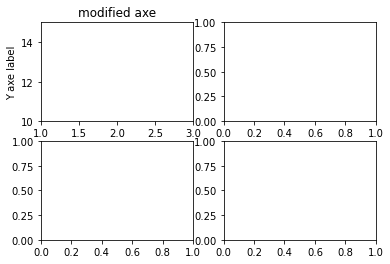

In [7]:
# get axe (1,1) using ax_list parameter
fig, ax_list = plt.subplots(nrows=2, ncols=2)
axe00 = ax_list[0,0] # get axe in position (1,1) in the grid
axe00.set_xlim(left=1, right=3) # set x_min and x_max
axe00.set_ylim(bottom=10, top=15) # set y_max and y_min
axe00.set_title("modified axe") # add title
axe00.set_ylabel(ylabel="Y axe label") # set y label
#fig.show()

Text(0.5, 1.0, 'modified axe')

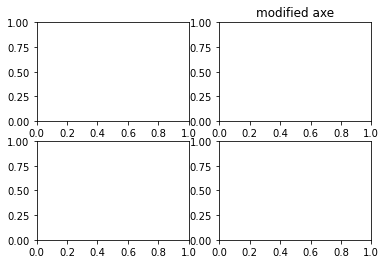

In [8]:
fig, ax_list = plt.subplots(nrows=2, ncols=2)
ax01 = fig.get_children()[2] # get second figure's axe 
ax01.set_title("modified axe")
#fig.show()

## 2.1 type of inputs to matplotlib 
* matplotlib plot functions expect numpy array or numpy masked array as input type

* classes that are array like pandas dataframes or matrix may not properly work, so it is best to convert them to numpy array before giving them to a matplotlib plot function 

# 3. Examples

In [9]:
import numpy as np

## 3.1 simple examples

### 3.1.2 example with one axe

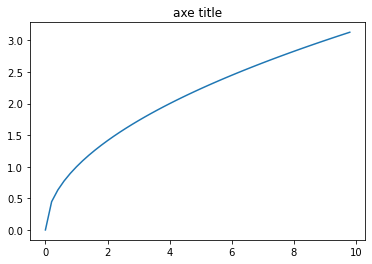

In [11]:
x = np.arange(0,10,0.2)
y = np.sqrt(x)
fig, axe = plt.subplots()
axe.set_title("axe title")
axe.plot(x, y)
plt.show()

### 3.1.2 example with multiple axes

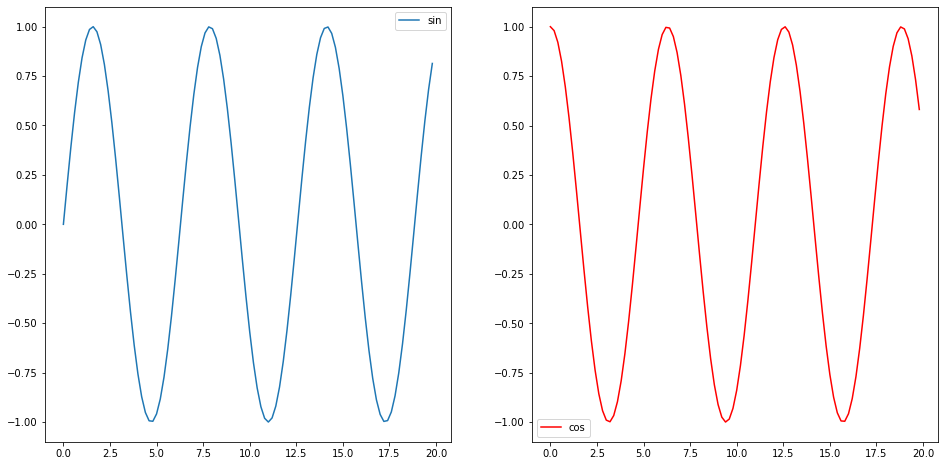

In [12]:
x = np.arange(0,20,0.2)
y1 = np.sin(x)
y2 = np.cos(x)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))
ax1.plot(x, y1, label="sin")
ax1.legend() # place label legend on the axe
ax2.plot(x, y2, label = "cos", color="red")
ax2.legend()
plt.show()


## 3.2 examples with iris data

In [13]:
X = iris.data
y = iris.target

In [13]:
print(type(iris))
dir(iris)

<class 'sklearn.utils.Bunch'>


['DESCR', 'data', 'feature_names', 'filename', 'target', 'target_names']

### 3.2.1 scatter plot

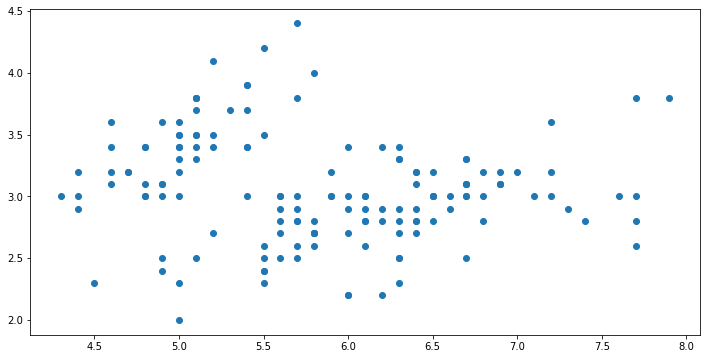

In [14]:
# Scatter plot Example
fig,ax1 = plt.subplots(1,1, figsize=(12,6))
ax1.scatter(X[:,0],X[:,1],label=iris.target_names)

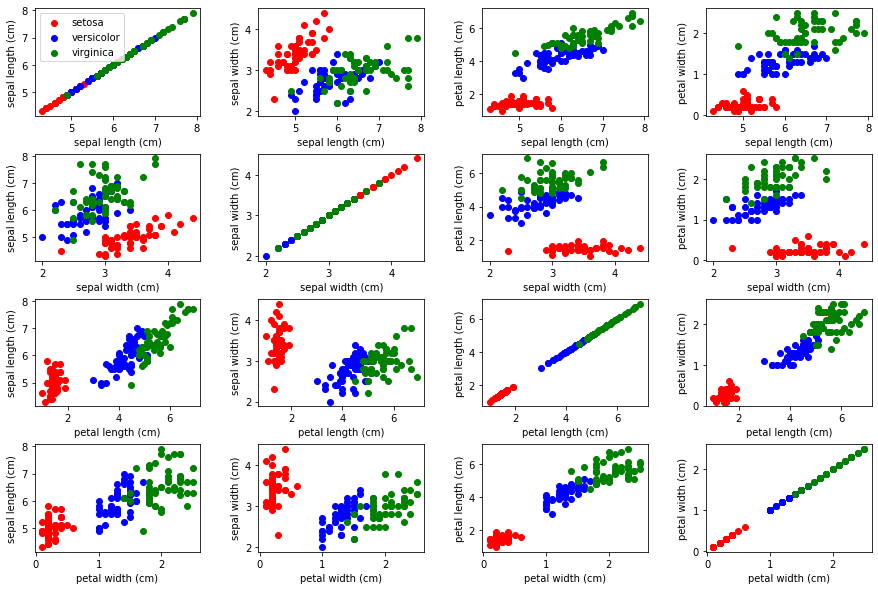

In [15]:
import numpy as np
fig, axs = plt.subplots(4,4, figsize=(15,10)) 
fig.subplots_adjust(wspace=0.35, hspace=0.35)
c_dict = {0:"red", 1:"blue", 2: "green"} # dict to map classes to colors
for i in range(4): 
    for j in range(4): # for each (i,j) features
        for c in range(3): # for each class
            i_c = np.where(y == c)  # indices of the class
            axs[i, j].scatter(X[:,i][i_c], X[:,j][i_c], c=c_dict[c], label=iris.target_names[c])
            # put the legend only on the first axe
            if (i,j)==(0,0):
                axs[i, j].legend()
            axs[i, j].set_xlabel(iris.feature_names[i])
            axs[i, j].set_ylabel(iris.feature_names[j])

### 3.2.1 box plot

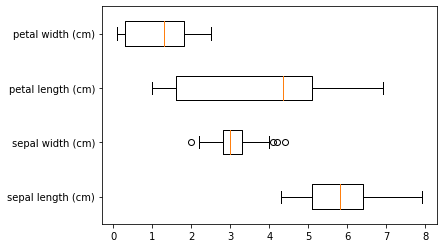

In [17]:
fig, ax = plt.subplots()
ax.boxplot(X, vert=False, labels=iris.feature_names) # vert=False to make plot horizontal
plt.show()

### 3.2.1 hist plot

Text(0.5, 1.0, 'histogramme en fréquence')

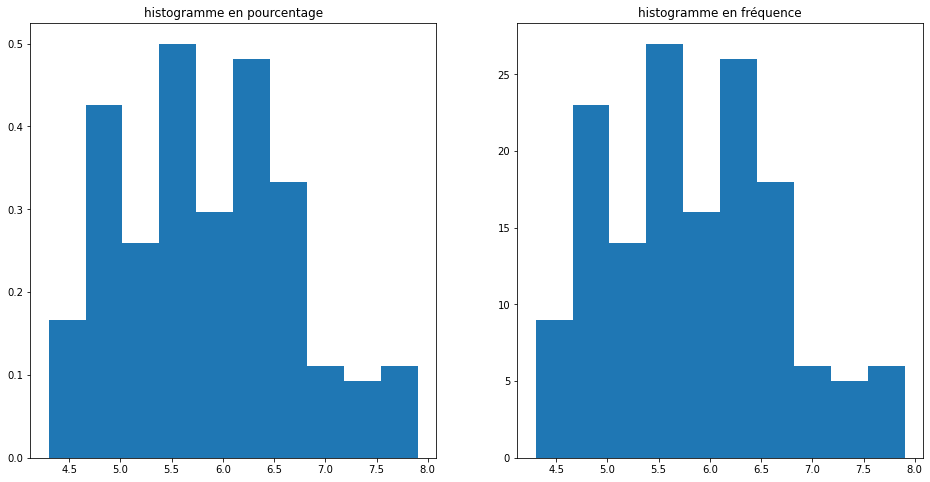

In [18]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))
ax1.hist(X[:,0], density=True, bins=10)
ax1.set_title("histogramme en pourcentage")

ax2.hist(X[:,0], density=False, bins=10)
ax2.set_title("histogramme en fréquence")

### 3.2.1 density plot

In [19]:
from scipy import stats
# kde estimate the probability density function (PDF) of a random variable in a non-parametric way
# en sortie de kde, on a donc un estimateur qui permet de représenter une densité
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html
kde = stats.gaussian_kde(X[:,0])
dir(kde)
# n : nombre de points utilisés
# d : dimension
print(kde.d,kde.n,kde.factor,kde.covariance)

1 150 0.36709777158498536 [[0.09240459]]


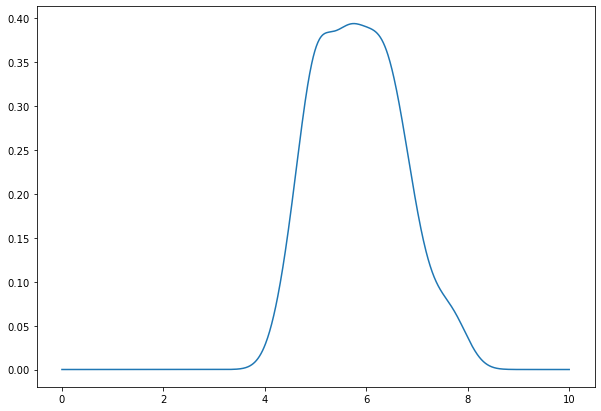

In [20]:
# pour représenter la densité, il faut maintenant générer des points et appliquer le kde dessus
datapoints = np.linspace(0, 10, 1000)
fig, ax1 = plt.subplots(figsize=(10,7))
ax1.plot(datapoints,kde(datapoints),label="densité de sepal length")

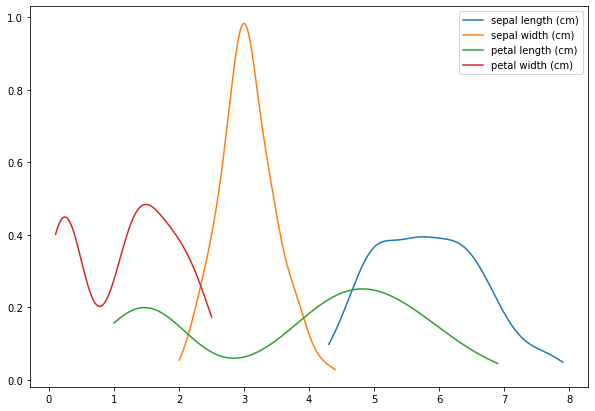

In [21]:
# En multivarié, on calcule le kde pour chaque série et on représente les 4 densités sur l'échelle étendue à tous les cas
from scipy import stats
fig, ax = plt.subplots(figsize=(10,7))
for i in range(4):
    kde = stats.gaussian_kde(X[:,i])
    xx = np.linspace(np.min(X[:,i]), np.max(X[:,i]), 1000)
    ax.plot(xx, kde(xx), label = iris.feature_names[i])
    ax.legend()
plt.show()

# 4. Seaborn
* Seaborn is a high level interface built on top of matplotlib
* it is a python library for making statistical graphics
* closely integrated with pandas data structures ( series and dataframes) 
* and it is a dataset oriented visualization tool, to plot and  examine relationships between variables 

In [22]:
import pandas as pd
import seaborn as sns
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)
iris_df["species"] = y
iris_df.head()

C:\Users\dgr\AppData\Local\Continuum\anaconda3\lib\site-packages\statsmodels\tools\_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [23]:
# on modifie les label
iris_df.columns=["sepal_length","sepal_width","petal_length","petal_width","species"]

# on crée une variable catégorielle pour les graphiques par espèces

iris_df.loc[iris_df.species==0, 'especes'] = 'setosa'
iris_df.loc[iris_df.species==1, 'especes'] = 'versicolor'
iris_df.loc[iris_df.species==2, 'especes'] = 'virginica'


iris_df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species           int32
especes          object
dtype: object

## 4.1 examples

In [24]:
type(iris_df.especes)
iris_df["especes"]=iris_df["especes"].astype('category')
iris_df.dtypes

sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species            int32
especes         category
dtype: object

In [25]:
type(iris_df.especes)

pandas.core.series.Series

In [26]:
iris_df.especes.value_counts()

virginica     50
versicolor    50
setosa        50
Name: especes, dtype: int64

C:\Users\dgr\AppData\Local\Continuum\anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


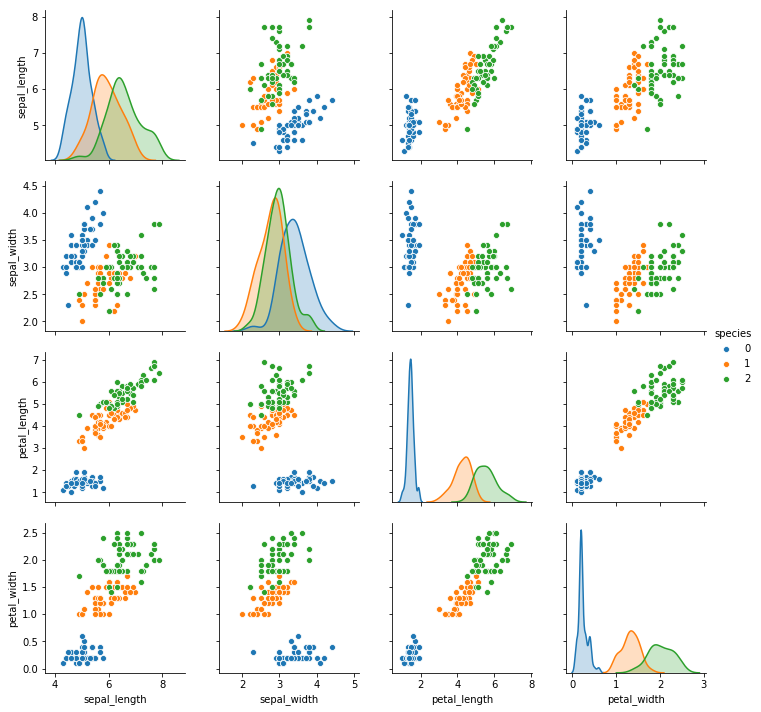

In [82]:
sns.pairplot(data=iris_df, vars=["sepal_length","sepal_width","petal_length","petal_width"], hue="species")

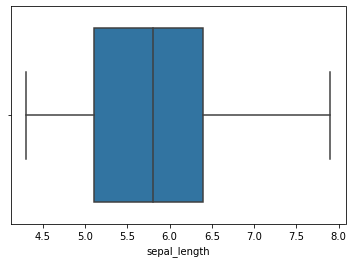

In [32]:
fig, (ax1) = plt.subplots()
sns.boxplot(x=iris_df.columns[0],data=iris_df, ax=ax1)

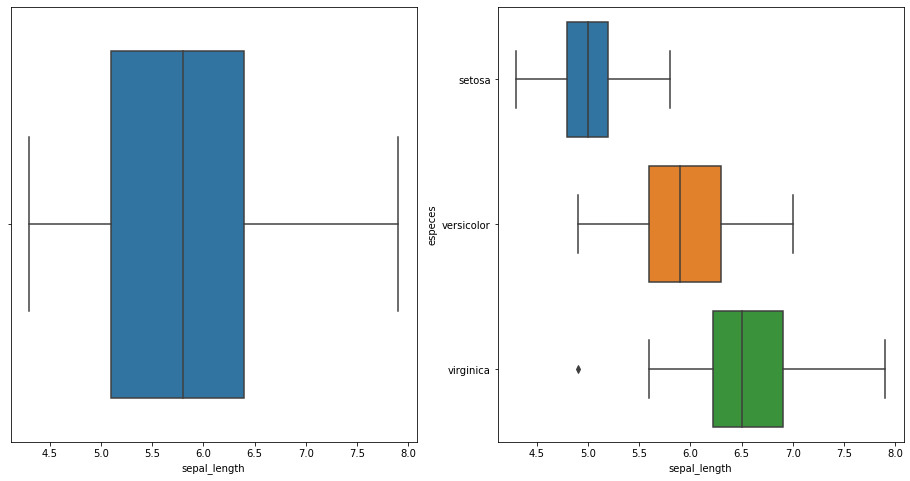

In [29]:
# box plot d'une variable par espèce (anova)
# Utiliser seaborn avec Axes de matplotlib
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))
sns.boxplot(x=iris_df.columns[0],data=iris_df, ax=ax1)
sns.boxplot(x=iris_df.columns[0],y='especes',data=iris_df, ax=ax2)

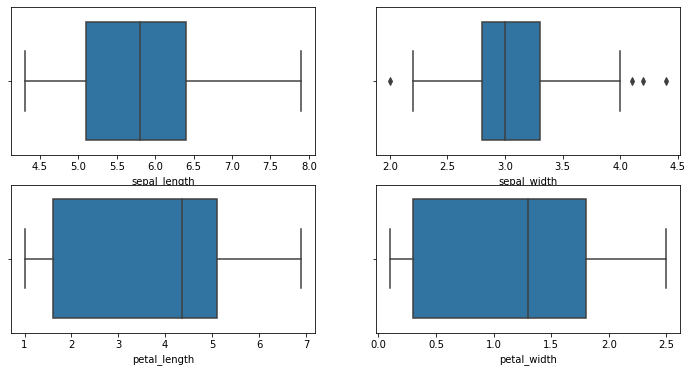

In [33]:
fig, list_ax = plt.subplots(2,2, figsize=(12,6))
for i in range(4):
    sns.boxplot(x=iris_df.columns[i], data = iris_df, ax=fig.get_children()[i+1], orient="h")

In [34]:
fig.get_children()[1]

C:\Users\dgr\AppData\Local\Continuum\anaconda3\lib\site-packages\seaborn\axisgrid.py:2065: UserWarning: The `size` parameter has been renamed to `height`; pleaes update your code.
  warnings.warn(msg, UserWarning)


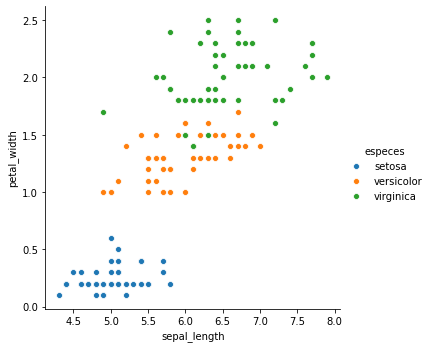

In [35]:
sns.pairplot(x_vars='sepal_length', y_vars='petal_width', data=iris_df,hue='especes',size=5)

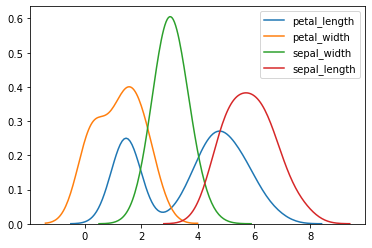

In [36]:
# KDE density
fig=plt.figure()
sns.kdeplot(iris_df['petal_length'], bw=0.5)
sns.kdeplot(iris_df['petal_width'], bw=0.5)
sns.kdeplot(iris_df['sepal_width'], bw=0.5)
sns.kdeplot(iris_df['sepal_length'], bw=0.5)

# 5. Pandas plot
* on the data structure of pandas there is a method plot used to visualiaze Pandas series and dataframes
*  `pandas.DataFrame.plot()` and `pandas.Series.plot()`
* These are methods implemented in pandas using matplotlib so that we can plot pandas dataframes and series using only pandas package 

## 5.1 exemples

In [37]:
iris_df.plot.scatter(x="sepal length (cm)", y="sepal width (cm)", c=iris_df["species"].apply(lambda x: c_dict[x]))

NameError: name 'c_dict' is not defined

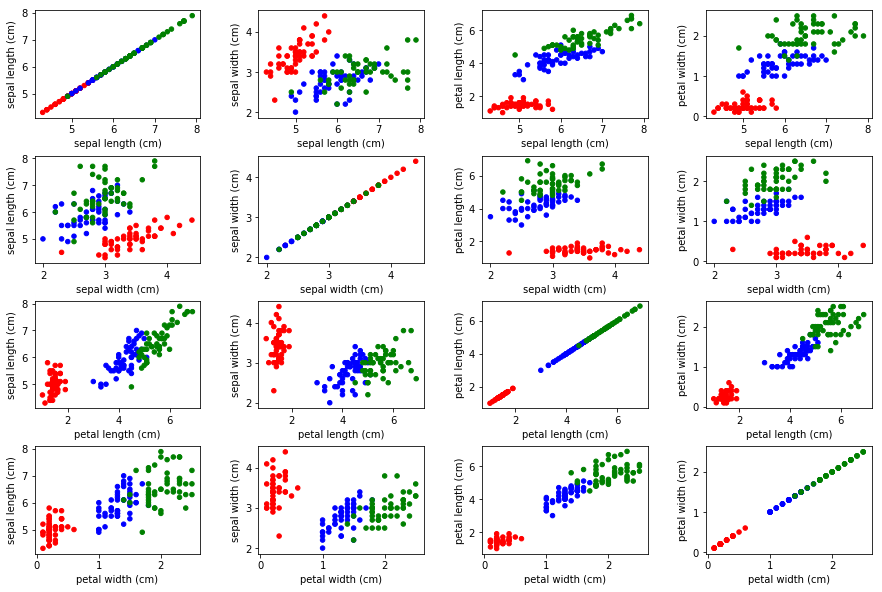

In [69]:
fig, axs = plt.subplots(4,4, figsize=(15,10)) 
fig.subplots_adjust(wspace=0.35, hspace=0.35)
for i, col1 in enumerate(iris_df.columns.tolist()[:-1]): 
    for j, col2 in enumerate(iris_df.columns.tolist()[:-1]):
        iris_df.plot.scatter(x=col1, y=col2, c=iris_df["species"].apply(lambda x: c_dict[x]), ax = axs[i, j])

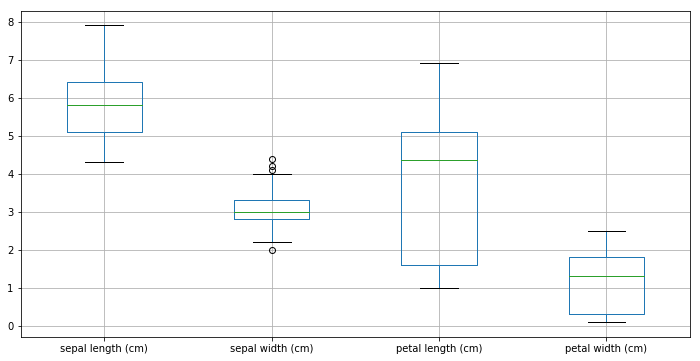

In [48]:
iris_df.boxplot(column=iris_df.columns[:-1].tolist(), figsize=(12,6))

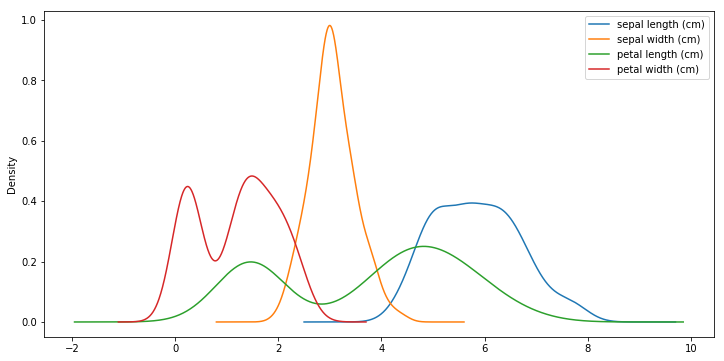

In [58]:
iris_df.iloc[:,:-1].plot.density(figsize=(12,6))